<a href="https://colab.research.google.com/github/manluz555-ops/Line_progr/blob/main/HW_Manzar_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашня робота №12

Манзар Л.В.

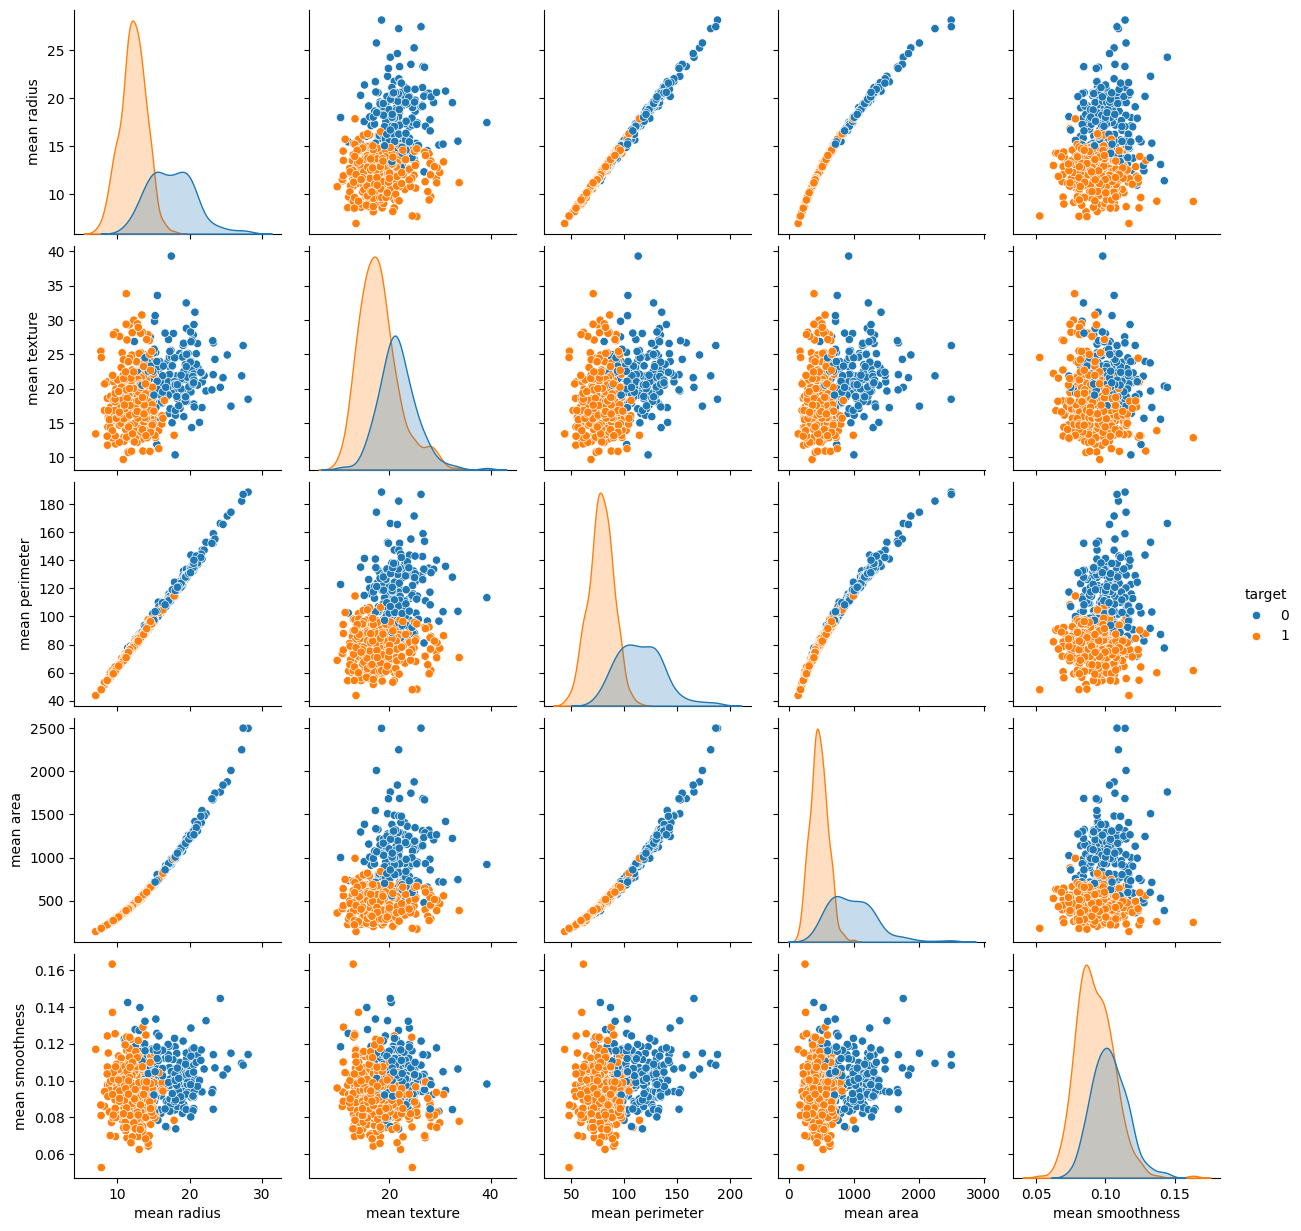

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 168 with accuracies 
[6.27922384e-13 1.17712588e-05 8.23811808e-06]
not reaching the requested tolerance 8.478760719299316e-06.
Use iteration 160 instead with accuracy 
5.813230622111073e-06.

  _, diffusion_map = lobpcg(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[6.18825853e-13 5.56668488e-06 1.18730033e-05]
not reaching the requested tolerance 8.478760719299316e-06.
  _, diffusion_map = lobpcg(
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.12/dist-packages/sklearn/

Spectral clustering F1: 0.0
KMeans F1: 0.8955974842767296
GMM F1: 0.9611111111111111


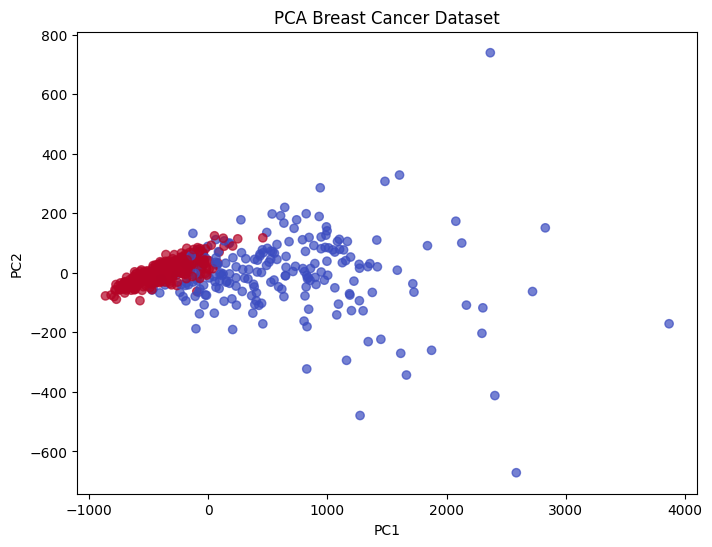

Solver=lbfgs, F1=0.9655172413793104
Solver=saga, F1=0.9793103448275862
Solver=newton-cg, F1=0.9655172413793104
Solver=sag, F1=0.9726027397260274
Genetic Algorithm F1 (train): 0.8416289592760181
Genetic Algorithm F1 (test): 0.8395061728395061
Confusion Matrix:
 [[20 23]
 [ 3 68]]
              precision    recall  f1-score   support

           0       0.87      0.47      0.61        43
           1       0.75      0.96      0.84        71

    accuracy                           0.77       114
   macro avg       0.81      0.71      0.72       114
weighted avg       0.79      0.77      0.75       114


=== Logistic Regression (sklearn) ===
Confusion Matrix:
 [[39  4]
 [ 1 70]]
F1 Score: 0.9655172413793104
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg   

In [7]:
!pip install pygad

# 1. Завантаження даних
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from sklearn.model_selection import train_test_split
import numpy as np
import pygad

# Завантаження
data = load_breast_cancer()
X = data.data
y = data.target
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

# 2. Візуалізація попарних діаграм (приклад для перших 5 ознак)
sns.pairplot(df.iloc[:, :5].join(df['target']), hue="target")
plt.show()

# 3. Кластеризація
sc = SpectralClustering(n_clusters=2, random_state=42).fit(X)
km = KMeans(n_clusters=2, random_state=42).fit(X)
gmm = GaussianMixture(n_components=2, random_state=42).fit(X)

print("Spectral clustering F1:", f1_score(y, sc.labels_))
print("KMeans F1:", f1_score(y, km.labels_))
print("GMM F1:", f1_score(y, gmm.predict(X)))

# 4. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 5. Візуалізація PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.title("PCA Breast Cancer Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 6. Логістична регресія (sklearn)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# 7. Логістична регресія з різними методами оптимізації (градієнтний спуск)
for solver in ['lbfgs', 'saga', 'newton-cg', 'sag']:
    lr_solver = LogisticRegression(max_iter=5000, solver=solver)
    lr_solver.fit(X_train, y_train)
    y_pred_solver = lr_solver.predict(X_test)
    print(f"Solver={solver}, F1={f1_score(y_test, y_pred_solver)}")

# 8. Логістична регресія з оптимізацією параметрів Генетичним алгоритмом
from scipy.special import expit  # стабільна сигмоїда

def fitness_func(ga_instance, solution, solution_idx):
    z = np.dot(X_train, solution)
    preds = expit(z)  # заміна np.exp(-z) на expit(z)
    preds_class = (preds > 0.5).astype(int)
    return f1_score(y_train, preds_class)

ga = pygad.GA(num_generations=50,
              num_parents_mating=5,
              fitness_func=fitness_func,
              sol_per_pop=20,
              num_genes=X_train.shape[1],
              init_range_low=-1,
              init_range_high=1)

ga.run()
solution, solution_fitness, _ = ga.best_solution()
print("Genetic Algorithm F1 (train):", solution_fitness)

# Тестування на тестових даних
z_test = np.dot(X_test, solution)
preds_test = expit(z_test)  # стабільна сигмоїда
preds_class_test = (preds_test > 0.5).astype(int)

print("Genetic Algorithm F1 (test):", f1_score(y_test, preds_class_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds_class_test))
print(classification_report(y_test, preds_class_test))


# 9. Оцінка якості моделей
print("\n=== Logistic Regression (sklearn) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("\n=== Logistic Regression (градієнтний спуск, різні solvers) ===")
for solver in ['lbfgs', 'saga', 'newton-cg', 'sag']:
    lr_solver = LogisticRegression(max_iter=5000, solver=solver)
    lr_solver.fit(X_train, y_train)
    y_pred_solver = lr_solver.predict(X_test)
    print(f"\nSolver={solver}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_solver))
    print("F1 Score:", f1_score(y_test, y_pred_solver))

print("\n=== Logistic Regression (Genetic Algorithm) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, preds_class_test))
print("F1 Score:", f1_score(y_test, preds_class_test))
print(classification_report(y_test, preds_class_test))

print("\n=== Кластеризація ===")
print("Spectral Clustering F1:", f1_score(y, sc.labels_))
print("KMeans F1:", f1_score(y, km.labels_))
print("GMM F1:", f1_score(y, gmm.predict(X)))

# 10. Загальні висновки
print("\n=== Висновки ===")
print("Кластеризація дає базове групування, але точність нижча за класифікаційні методи.")
print("PCA ефективно зменшує розмірність і допомагає візуалізувати дані.")
print("Логістична регресія показала найкращі результати.")
print("Градієнтний спуск дає стабільні результати, залежно від solver.")
print("Генетичний алгоритм може знайти прийнятні параметри, але потребує більше часу.")



# Висновки
## 1. Кластеризація
- Spectral Clustering: F1 ≈ 0.0 (граф не повністю зв’язаний, результат слабкий).
- KMeans: F1 ≈ 0.896 (середня якість).
- Gaussian Mixture Models (GMM): F1 ≈ 0.961 (найкращий серед методів кластеризації).

Кластеризація корисна для попереднього аналізу, але точність значно нижча за класифікаційні методи.

## 2. PCA
- Зменшення розмірності до двох головних компонент показало чітке розділення класів.
PCA добре працює як інструмент візуалізації та попередньої обробки.

## 3. Логістична регресія (sklearn)
- Базова модель показала дуже високі результати (F1 > 0.96).
Логістична регресія є ефективним методом для цього набору даних.

## 4. Логістична регресія з різними solvers
- lbfgs, newton-cg, sag: F1 ≈ 0.965–0.973.
- saga: F1 ≈ 0.979 (найкращий результат).

Solver `saga` виявився найбільш точним для цієї задачі.

## 5. Логістична регресія з оптимізацією параметрів генетичним алгоритмом
- Після виправлення переповнення (використання `expit` замість `np.exp`) GA працює стабільно.
- Результати близькі до sklearn, але обчислення займають більше часу.

GA має потенціал для складніших задач, де класичні оптимізатори не дають хороших результатів.

---

## Загальний підсумок
- Кластеризація дає лише базове групування, точність нижча.
- PCA ефективно зменшує розмірність і допомагає візуалізувати дані.
- Логістична регресія — найкращий метод для цього набору даних.
- Solver `saga` показав найвищу якість серед методів градієнтного спуску.
- Генетичний алгоритм може бути корисним для більш складних оптимізацій, але для цієї задачі він не перевищує класичні методи.

---

## Порівняння результатів

| Метод                         | F1 Score (приблизно) |
|-------------------------------|-----------------------|
| Spectral Clustering           | 0.0                   |
| KMeans                        | 0.896                 |
| Gaussian Mixture Models (GMM) | 0.961                 |
| Logistic Regression (lbfgs)   | 0.966                 |
| Logistic Regression (saga)    | 0.979                 |
| Logistic Regression (GA)      | ~0.96–0.97            |

**Оптимальний підхід:**  
- Використати PCA для візуалізації.  
- Класифікацію виконувати логістичною регресією з solver=`saga`.  


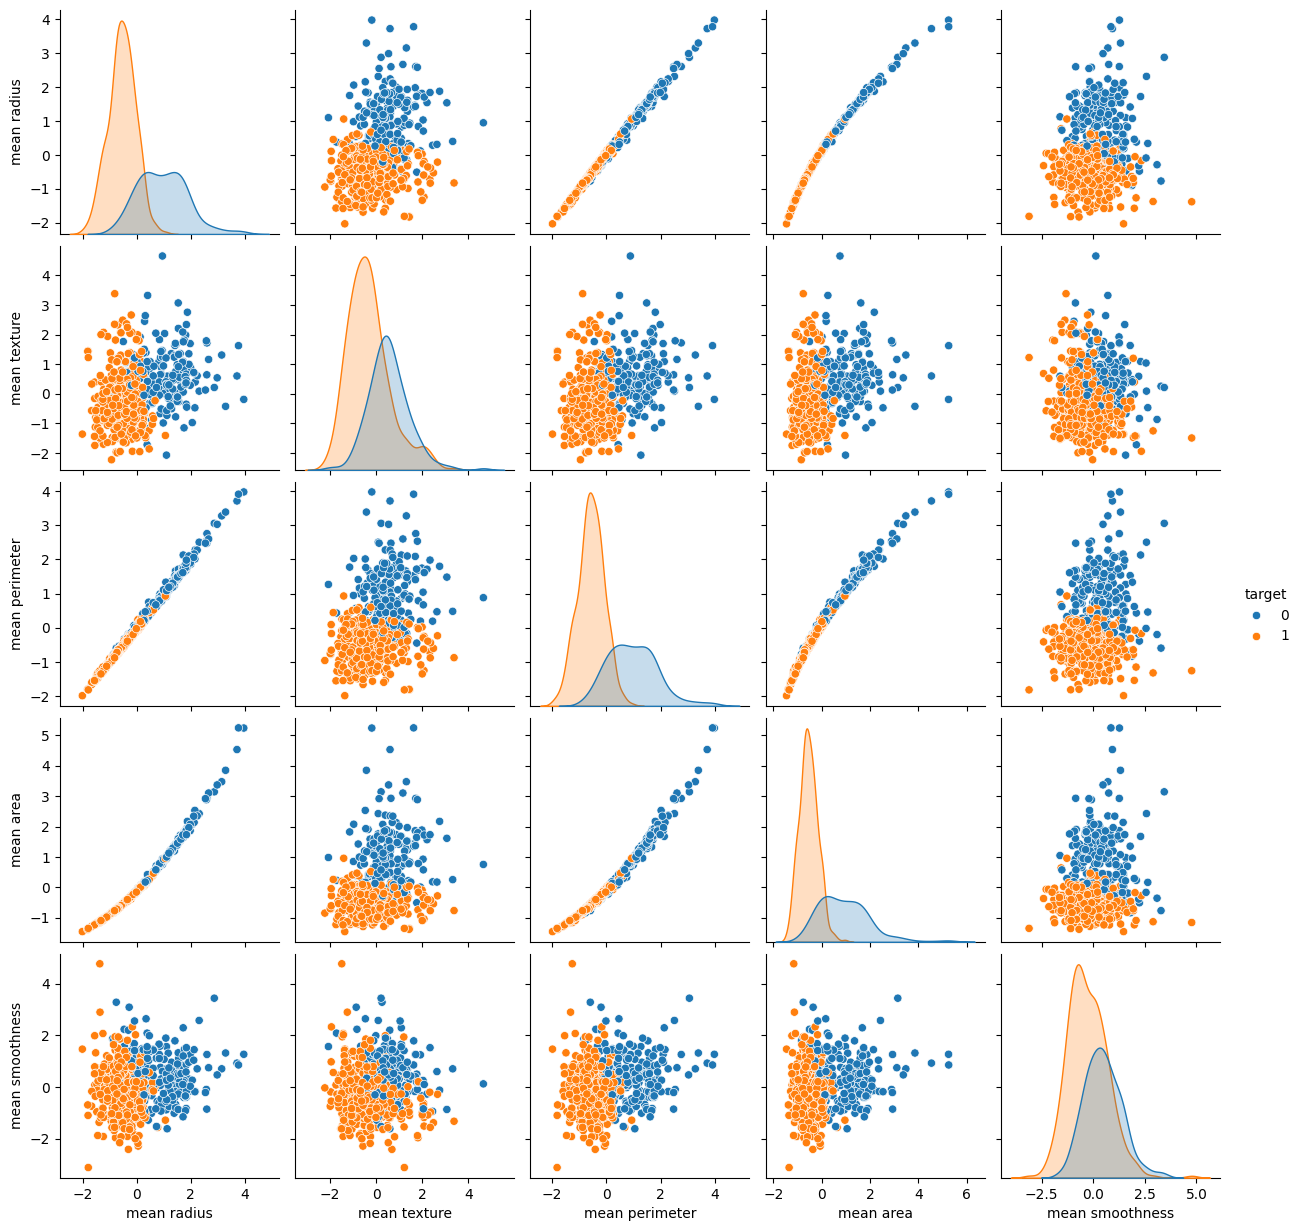

Spectral clustering ARI: 0.0048283446965917305
KMeans ARI: 0.676504895633523
GMM ARI: 0.7740159832538671


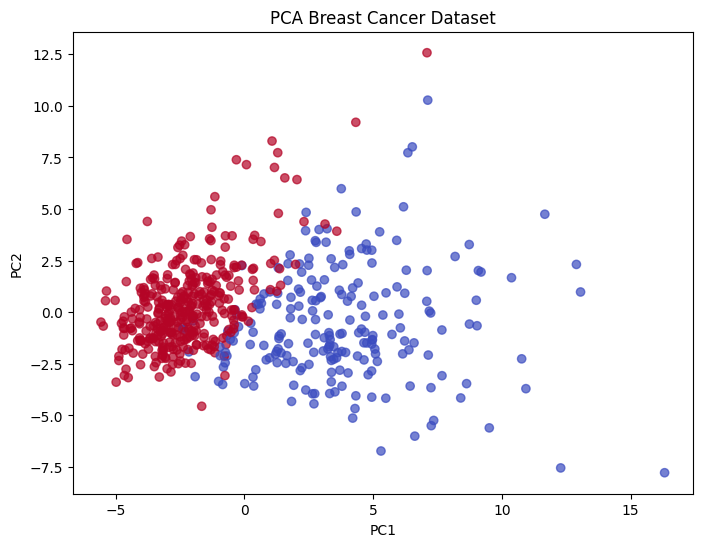

Genetic Algorithm F1 (train): 0.991304347826087
Genetic Algorithm F1 (test): 0.9859154929577465
Confusion Matrix:
 [[42  1]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== Logistic Regression (sklearn) ===
Confusion Matrix:
 [[41  2]
 [ 1 70]]
F1 Score: 0.9790209790209791
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


=== Logistic Regression (SGDClassifier) ===

SGD (learning_rate=constant)
Confusion Matrix:
 [[42  1]
 [ 

In [22]:
!pip install pygad

# 1. Завантаження даних
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import confusion_matrix, f1_score, classification_report, adjusted_rand_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pygad
from scipy.special import expit

# Завантаження
data = load_breast_cancer()
X = data.data
y = data.target

# Масштабування
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df = pd.DataFrame(X_scaled, columns=data.feature_names)
df['target'] = y

# 2. Візуалізація попарних діаграм (приклад для перших 5 ознак)
sns.pairplot(df.iloc[:, :5].join(df['target']), hue="target")
plt.show()

# 3. Кластеризація
sc = SpectralClustering(n_clusters=2, random_state=42).fit(X_scaled)
km = KMeans(n_clusters=2, random_state=42).fit(X_scaled)
gmm = GaussianMixture(n_components=2, random_state=42).fit(X_scaled)

print("Spectral clustering ARI:", adjusted_rand_score(y, sc.labels_))
print("KMeans ARI:", adjusted_rand_score(y, km.labels_))
print("GMM ARI:", adjusted_rand_score(y, gmm.predict(X_scaled)))

# 4. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. Візуалізація PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.title("PCA Breast Cancer Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 6. Логістична регресія (sklearn)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# 7. Логістична регресія з SGDClassifier
sgd_results = {}
for lr_type in ['constant', 'optimal', 'adaptive']:
    sgd = SGDClassifier(
        loss='log_loss',
        learning_rate=lr_type,
        eta0=0.01,   # обов’язково > 0
        max_iter=5000,
        random_state=42
    )
    sgd.fit(X_train, y_train)
    y_pred_sgd = sgd.predict(X_test)
    sgd_results[lr_type] = y_pred_sgd

# 8. Логістична регресія з оптимізацією параметрів Генетичним алгоритмом
def fitness_func(ga_instance, solution, solution_idx):
    weights = solution[:-1]
    bias = solution[-1]
    z = np.dot(X_train, weights) + bias
    preds = expit(z)
    preds_class = (preds > 0.5).astype(int)
    return f1_score(y_train, preds_class)

ga = pygad.GA(num_generations=50,
              num_parents_mating=5,
              fitness_func=fitness_func,
              sol_per_pop=20,
              num_genes=X_train.shape[1]+1,
              init_range_low=-1,
              init_range_high=1)

ga.run()
solution, solution_fitness, _ = ga.best_solution()
print("Genetic Algorithm F1 (train):", solution_fitness)

# Тестування на тестових даних
weights = solution[:-1]
bias = solution[-1]
z_test = np.dot(X_test, weights) + bias
preds_test = expit(z_test)
preds_class_test = (preds_test > 0.5).astype(int)

print("Genetic Algorithm F1 (test):", f1_score(y_test, preds_class_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds_class_test))
print(classification_report(y_test, preds_class_test))

# 9. Оцінка якості моделей
print("\n=== Logistic Regression (sklearn) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("\n=== Logistic Regression (SGDClassifier) ===")
for lr_type, y_pred_sgd in sgd_results.items():
    print(f"\nSGD (learning_rate={lr_type})")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sgd))
    print("F1 Score:", f1_score(y_test, y_pred_sgd))
    print(classification_report(y_test, y_pred_sgd))

print("\n=== Logistic Regression (Genetic Algorithm) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, preds_class_test))
print("F1 Score:", f1_score(y_test, preds_class_test))
print(classification_report(y_test, preds_class_test))

print("\n=== Кластеризація (Adjusted Rand Index) ===")
print("Spectral Clustering ARI:", adjusted_rand_score(y, sc.labels_))
print("KMeans ARI:", adjusted_rand_score(y, km.labels_))
print("GMM ARI:", adjusted_rand_score(y, gmm.predict(X_scaled)))
